In [1]:
!pip install xgboost lightgbm catboost pandas numpy scikit-learn

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_squared_error, r2_score)
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate

In [3]:
ownership_threshold_log = 10
imp_threshold = 0.003
corr_threshold = 0.90
verbose = False

In [4]:
# Code for correlation analysis and feature selection

import numpy as np

def get_top_correlations(df, top_n=30, threshold=0.90, verbose=False):
    corr_matrix = df.corr().abs()  # Get absolute correlation values
    corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # upper triangle only
    .stack()
    .reset_index()
    )
    corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    corr_pairs = corr_pairs.sort_values('Correlation', ascending=False)

    if verbose:
        print("Top 30 most correlated feature pairs:")
        print(corr_pairs.head(30).to_string(index=False))

    to_drop = get_highly_correlated_features(corr_pairs, threshold=threshold, verbose=verbose)

    return to_drop


def get_highly_correlated_features(corr_pairs, threshold=0.90, verbose=False):
    to_drop = set()

    for _, row in corr_pairs.iterrows():
        f1, f2, corr = row['Feature 1'], row['Feature 2'], row['Correlation']
        if corr < threshold:
            break  # already sorted descending, so we can stop early
        # Drop f2 (keep f1) — unless f1 is already marked for dropping
        if f1 not in to_drop:
            to_drop.add(f2)

    if verbose:
        print(f"Features to drop ({len(to_drop)}):")
        print(sorted(to_drop))

    return to_drop

In [6]:
# load data and importance scores
df_final = pd.read_csv('./cleaned_dataset/steam_finalized_dataset.csv')
importance_df = pd.read_csv('./cleaned_dataset/feature_importances.csv')
df_final = df_final[df_final['owners_log'] >= ownership_threshold_log]

print(f"Dataset shape after filtering: {df_final.shape}")

Dataset shape after filtering: (8319, 499)


In [7]:
# feature selection — lower threshold to capture more tag/genre signal
selected_features = importance_df[
    importance_df['importance'] > imp_threshold
]['feature'].tolist()

# playtime sits just below threshold but is informative?
for col in ['average_playtime', 'median_playtime']:
    if col in df_final.columns and col not in selected_features:
        selected_features.append(col)

print(f"Selected {len(selected_features)} features (importance > {imp_threshold})")

Selected 40 features (importance > 0.003)


In [8]:
le = LabelEncoder()   # 5-class encoder
le3 = LabelEncoder()  # 3-class encoder
n=30

to_drop = get_top_correlations(df_final[selected_features], top_n=30, threshold=corr_threshold, verbose=verbose)

X = df_final[selected_features].drop(columns=to_drop)
y_reg = df_final['wilson_score']
y_clf = le.fit_transform(df_final['rating_category'])

# collapsed 3-class target: Bad / Mixed / Good
merge_map = {
    'Negative':        'Bad',
    'Mostly Negative': 'Bad',
    'Mixed':           'Mixed',
    'Mostly Positive': 'Good',
    'Positive':        'Good',
}
y_clf3 = le3.fit_transform(df_final['rating_category'].map(merge_map))

X_train, X_test, y_clf_train, y_clf_test, y_clf3_train, y_clf3_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_clf3, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Train distribution (5-class):")
print(pd.Series(le.inverse_transform(y_clf_train)).value_counts(normalize=True).round(3))
print("\nTest distribution (5-class):")
print(pd.Series(le.inverse_transform(y_clf_test)).value_counts(normalize=True).round(3))
print("\nTrain distribution (3-class):")
print(pd.Series(le3.inverse_transform(y_clf3_train)).value_counts(normalize=True).round(3))

Train distribution (5-class):
Positive           0.328
Mostly Positive    0.282
Mixed              0.259
Mostly Negative    0.112
Negative           0.019
Name: proportion, dtype: float64

Test distribution (5-class):
Positive           0.328
Mostly Positive    0.282
Mixed              0.259
Mostly Negative    0.112
Negative           0.019
Name: proportion, dtype: float64

Train distribution (3-class):
Good     0.610
Mixed    0.259
Bad      0.131
Name: proportion, dtype: float64


In [9]:
# Raw versions
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

class TargetEncoderCV(BaseEstimator, TransformerMixin):
    """Target encodes a column using only the fold's training data."""
    def __init__(self, col):
        self.col = col

    def fit(self, X, y):
        X_ = X.copy() if hasattr(X, 'copy') else pd.DataFrame(X)
        self.enc_map_    = pd.Series(y).groupby(
            X_[self.col] if isinstance(X_, pd.DataFrame) else X_[:, self.col]
        ).mean()
        self.global_mean_ = float(pd.Series(y).mean())
        return self

    def transform(self, X):
        X_ = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        X_['developer_enc'] = X_[self.col].map(self.enc_map_).fillna(self.global_mean_)
        X_.drop(columns=[self.col], inplace=True)
        return X_


def make_clf_pipeline(model, scale=False):
    steps = [('target_enc', TargetEncoderCV(col='developer'))]
    # steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

def make_reg_pipeline(model, scale=False):
    steps = [('target_enc', TargetEncoderCV(col='developer'))]
    # steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

In [12]:
# Cross validation setup
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
clf_pipelines = {
    'Naive Bayes':         make_clf_pipeline(GaussianNB(), scale=True),
    'Logistic Regression': make_clf_pipeline(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), scale=True),
    'Random Forest':       make_clf_pipeline(
        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')),
    'XGBoost':             make_clf_pipeline(
        XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      random_state=42, eval_metric='mlogloss', verbosity=0)),
    # 'LightGBM':            make_clf_pipeline(
    #     LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
    #                    subsample=0.8, colsample_bytree=0.8,
    #                    class_weight='balanced', random_state=42, verbose=-1)),
    'KNN':                 make_clf_pipeline(KNeighborsClassifier(n_neighbors=10, n_jobs=-1), scale=True),
}

clf3_pipelines = {
    'Naive Bayes':         make_clf_pipeline(GaussianNB(), scale=True),
    'Logistic Regression': make_clf_pipeline(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), scale=True),
    'Random Forest':       make_clf_pipeline(
        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')),
    'XGBoost':             make_clf_pipeline(
        XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      random_state=42, eval_metric='mlogloss', verbosity=0)),
    'KNN':                 make_clf_pipeline(KNeighborsClassifier(n_neighbors=10, n_jobs=-1), scale=True),
    # 'LightGBM':            make_clf_pipeline(
    #     LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
    #                    subsample=0.8, colsample_bytree=0.8,
    #                    class_weight='balanced', random_state=42, verbose=-1)),
}

reg_pipelines = {
    'Linear Regression': make_reg_pipeline(LinearRegression(), scale=True),
    'Random Forest':     make_reg_pipeline(
        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    'XGBoost':           make_reg_pipeline(
        XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, verbosity=0)),
}

In [14]:
# CLASSIFICATION (5-class) — 5-Fold Stratified CV
print("CLASSIFICATION 5-CLASS — 5-Fold Stratified CV")
print("=" * 60)

clf_cv_results = {}
for name, pipe in clf_pipelines.items():
    scores = cross_validate(
        pipe, X_train_raw, y_clf_train,
        cv=cv_clf,
        scoring=['accuracy', 'f1_weighted'],
        n_jobs=-1
    )
    clf_cv_results[name] = {
        'CV Acc (mean)': scores['test_accuracy'].mean(),
        'CV Acc (std)':  scores['test_accuracy'].std(),
        'CV F1 (mean)':  scores['test_f1_weighted'].mean(),
        'CV F1 (std)':   scores['test_f1_weighted'].std(),
    }
    print(f"{name:22s} | Acc = {scores['test_accuracy'].mean():.4f} "
          f"± {scores['test_accuracy'].std():.4f} | "
          f"F1 = {scores['test_f1_weighted'].mean():.4f} "
          f"± {scores['test_f1_weighted'].std():.4f}")

# CLASSIFICATION (3-class) — 5-Fold Stratified CV
print("\nCLASSIFICATION 3-CLASS (Bad/Mixed/Good) — 5-Fold Stratified CV")
print("=" * 60)

cv_clf3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf3_cv_results = {}
for name, pipe in clf3_pipelines.items():
    scores = cross_validate(
        pipe, X_train_raw, y_clf3_train,
        cv=cv_clf3,
        scoring=['accuracy', 'f1_weighted'],
        n_jobs=-1
    )
    clf3_cv_results[name] = {
        'CV Acc (mean)': scores['test_accuracy'].mean(),
        'CV Acc (std)':  scores['test_accuracy'].std(),
        'CV F1 (mean)':  scores['test_f1_weighted'].mean(),
        'CV F1 (std)':   scores['test_f1_weighted'].std(),
    }
    print(f"{name:22s} | Acc = {scores['test_accuracy'].mean():.4f} "
          f"± {scores['test_accuracy'].std():.4f} | "
          f"F1 = {scores['test_f1_weighted'].mean():.4f} "
          f"± {scores['test_f1_weighted'].std():.4f}")

CLASSIFICATION 5-CLASS — 5-Fold Stratified CV


Naive Bayes            | Acc = 0.1677 ± 0.0081 | F1 = 0.2067 ± 0.0106
Logistic Regression    | Acc = 0.3540 ± 0.0085 | F1 = 0.3787 ± 0.0088
Random Forest          | Acc = 0.4748 ± 0.0129 | F1 = 0.4599 ± 0.0117
XGBoost                | Acc = 0.4771 ± 0.0163 | F1 = 0.4701 ± 0.0148
KNN                    | Acc = 0.3737 ± 0.0137 | F1 = 0.3723 ± 0.0144

CLASSIFICATION 3-CLASS (Bad/Mixed/Good) — 5-Fold Stratified CV
Logistic Regression    | Acc = 0.5363 ± 0.0067 | F1 = 0.5620 ± 0.0049
Random Forest          | Acc = 0.6627 ± 0.0081 | F1 = 0.6251 ± 0.0103
XGBoost                | Acc = 0.6652 ± 0.0039 | F1 = 0.6456 ± 0.0072
KNN                    | Acc = 0.5845 ± 0.0088 | F1 = 0.5567 ± 0.0073


In [15]:
# REGRESSION — 5-Fold CV
print("REGRESSION — 5-Fold KFold CV")
print("=" * 50)

reg_cv_results = {}
for name, pipe in reg_pipelines.items():
    scores = cross_validate(
        pipe, X_train_raw, y_reg_train,
        cv=cv_reg,
        scoring=['r2', 'neg_root_mean_squared_error'],
        n_jobs=-1
    )
    reg_cv_results[name] = {
        'CV R² (mean)':   scores['test_r2'].mean(),
        'CV R² (std)':    scores['test_r2'].std(),
        'CV RMSE (mean)': -scores['test_neg_root_mean_squared_error'].mean(),
        'CV RMSE (std)':  scores['test_neg_root_mean_squared_error'].std(),
    }
    print(f"{name:22s} | R² = {scores['test_r2'].mean():.4f} "
          f"± {scores['test_r2'].std():.4f} | "
          f"RMSE = {-scores['test_neg_root_mean_squared_error'].mean():.4f} "
          f"± {scores['test_neg_root_mean_squared_error'].std():.4f}")

REGRESSION — 5-Fold KFold CV
Linear Regression      | R² = 0.1702 ± 0.0151 | RMSE = 0.1819 ± 0.0046
Random Forest          | R² = 0.1977 ± 0.0139 | RMSE = 0.1789 ± 0.0046
XGBoost                | R² = 0.2592 ± 0.0145 | RMSE = 0.1719 ± 0.0048


In [16]:
print("\nFINAL TEST SET — CLASSIFICATION (5-class)")
print("=" * 50)

clf_test_results = {}
for name, pipe in clf_pipelines.items():
    pipe.fit(X_train_raw, y_clf_train)
    preds = pipe.predict(X_test_raw)
    acc = accuracy_score(y_clf_test, preds)
    clf_test_results[name] = acc
    print(f"\n{name} — Test Accuracy: {acc:.4f}")
    print(classification_report(y_clf_test, preds, target_names=le.classes_))

print("\nFINAL TEST SET — CLASSIFICATION (3-class: Bad/Mixed/Good)")
print("=" * 50)

clf3_test_results = {}
for name, pipe in clf3_pipelines.items():
    pipe.fit(X_train_raw, y_clf3_train)
    preds = pipe.predict(X_test_raw)
    acc = accuracy_score(y_clf3_test, preds)
    clf3_test_results[name] = acc
    print(f"\n{name} — Test Accuracy: {acc:.4f}")
    print(classification_report(y_clf3_test, preds, target_names=le3.classes_))

print("\nFINAL TEST SET — REGRESSION")
print("=" * 50)

reg_test_results = {}
for name, pipe in reg_pipelines.items():
    pipe.fit(X_train_raw, y_reg_train)
    preds = pipe.predict(X_test_raw)
    r2   = r2_score(y_reg_test, preds)
    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
    reg_test_results[name] = {'R²': r2, 'RMSE': rmse}
    print(f"{name:22s} | R² = {r2:.4f} | RMSE = {rmse:.4f}")


FINAL TEST SET — CLASSIFICATION (5-class)

Naive Bayes — Test Accuracy: 0.1569
                 precision    recall  f1-score   support

          Mixed       0.16      0.14      0.15       431
Mostly Negative       0.09      0.10      0.10       186
Mostly Positive       0.28      0.11      0.15       469
       Negative       0.04      0.91      0.07        32
       Positive       0.81      0.19      0.31       546

       accuracy                           0.16      1664
      macro avg       0.28      0.29      0.16      1664
   weighted avg       0.40      0.16      0.20      1664


Logistic Regression — Test Accuracy: 0.3714
                 precision    recall  f1-score   support

          Mixed       0.39      0.23      0.29       431
Mostly Negative       0.25      0.43      0.31       186
Mostly Positive       0.38      0.28      0.32       469
       Negative       0.06      0.59      0.11        32
       Positive       0.67      0.53      0.59       546

       accuracy

In [17]:
# Summary Tables
print("\nCLASSIFICATION SUMMARY (5-class)")
clf_summary = pd.DataFrame(clf_cv_results).T
clf_summary['Test Accuracy'] = pd.Series(clf_test_results)
print(clf_summary.sort_values('CV Acc (mean)', ascending=False).round(4))

print("\nCLASSIFICATION SUMMARY (3-class: Bad/Mixed/Good)")
clf3_summary = pd.DataFrame(clf3_cv_results).T
clf3_summary['Test Accuracy'] = pd.Series(clf3_test_results)
print(clf3_summary.sort_values('CV Acc (mean)', ascending=False).round(4))

print("\nREGRESSION SUMMARY")
reg_summary = pd.DataFrame(reg_cv_results).T
reg_summary['Test R²']   = pd.Series({k: v['R²']   for k, v in reg_test_results.items()})
reg_summary['Test RMSE'] = pd.Series({k: v['RMSE'] for k, v in reg_test_results.items()})
print(reg_summary.sort_values('CV R² (mean)', ascending=False).round(4))


CLASSIFICATION SUMMARY (5-class)
                     CV Acc (mean)  CV Acc (std)  CV F1 (mean)  CV F1 (std)  \
XGBoost                     0.4771        0.0163        0.4701       0.0148   
Random Forest               0.4748        0.0129        0.4599       0.0117   
KNN                         0.3737        0.0137        0.3723       0.0144   
Logistic Regression         0.3540        0.0085        0.3787       0.0088   
Naive Bayes                 0.1677        0.0081        0.2067       0.0106   

                     Test Accuracy  
XGBoost                     0.5084  
Random Forest               0.4976  
KNN                         0.3858  
Logistic Regression         0.3714  
Naive Bayes                 0.1569  

CLASSIFICATION SUMMARY (3-class: Bad/Mixed/Good)
                     CV Acc (mean)  CV Acc (std)  CV F1 (mean)  CV F1 (std)  \
XGBoost                     0.6652        0.0039        0.6456       0.0072   
Random Forest               0.6627        0.0081        0.625

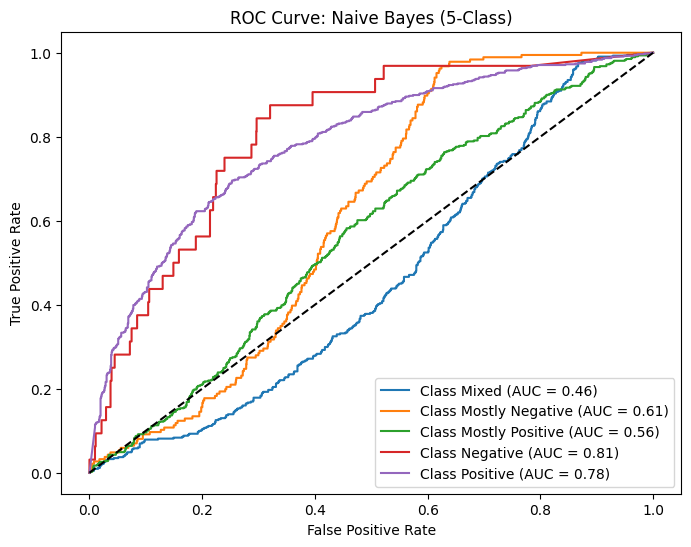

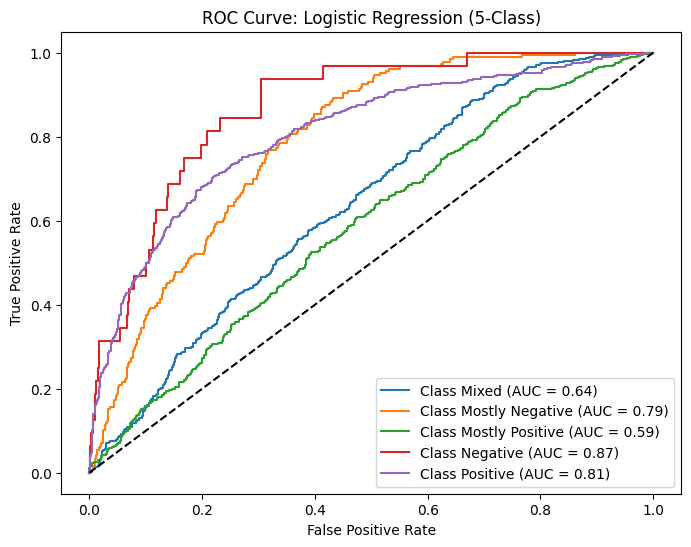

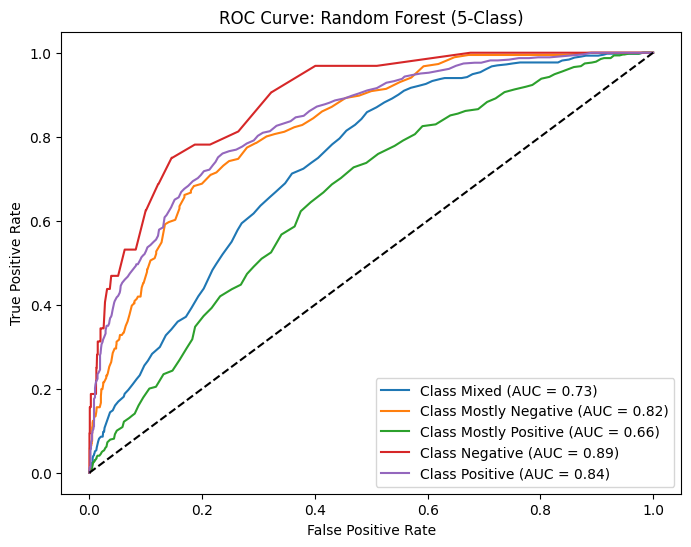

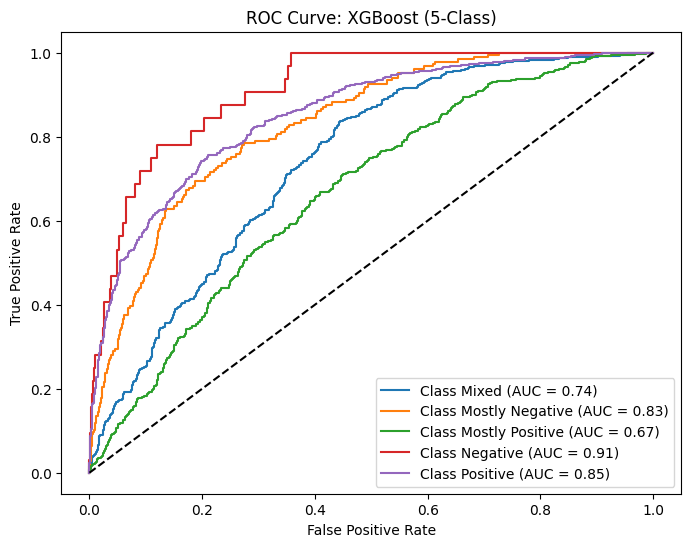

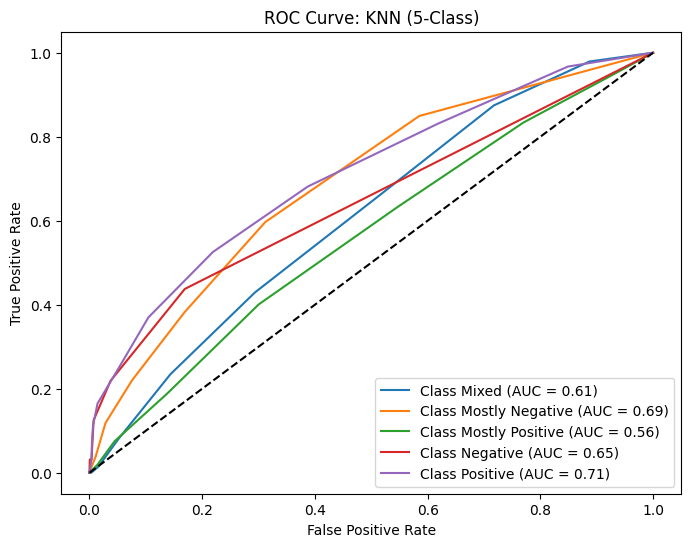

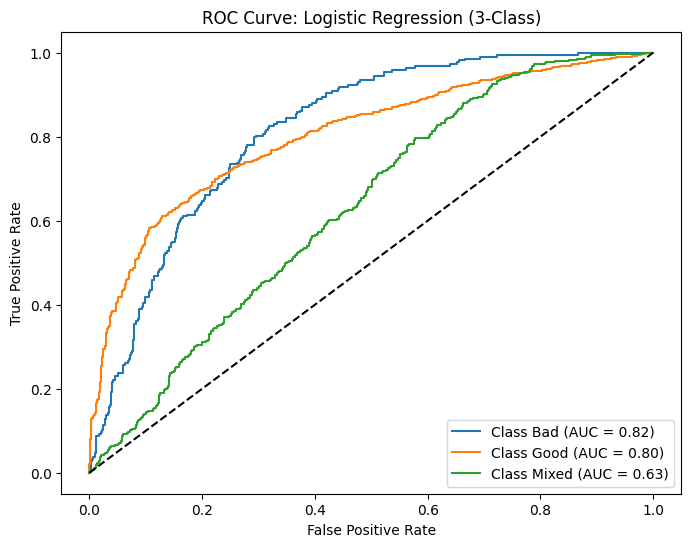

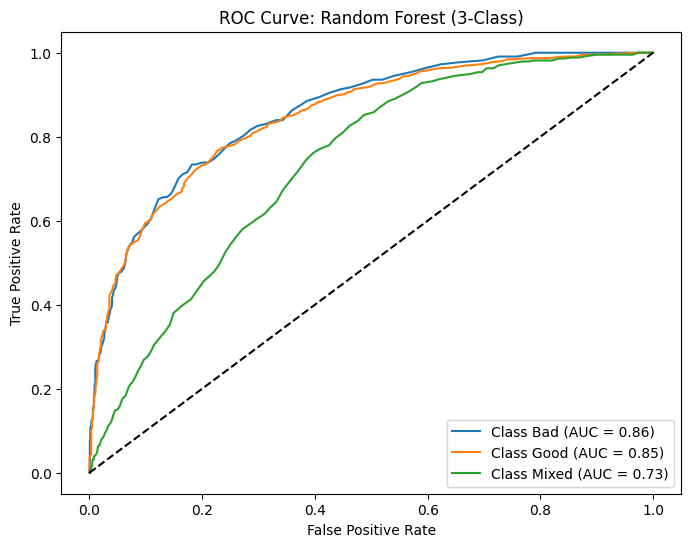

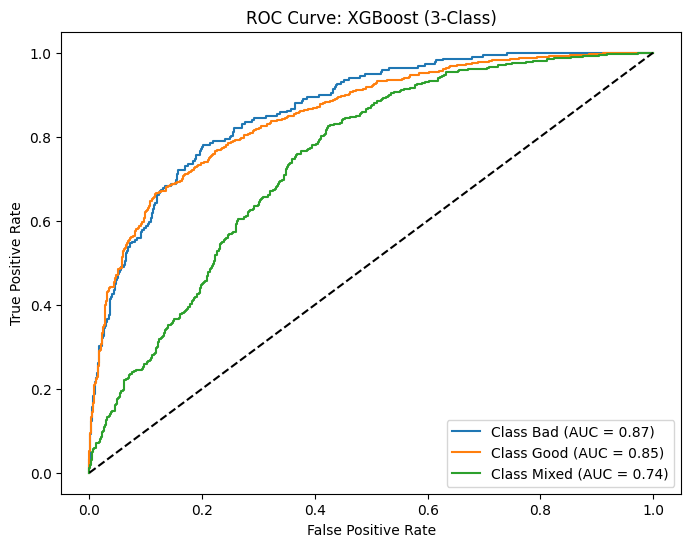

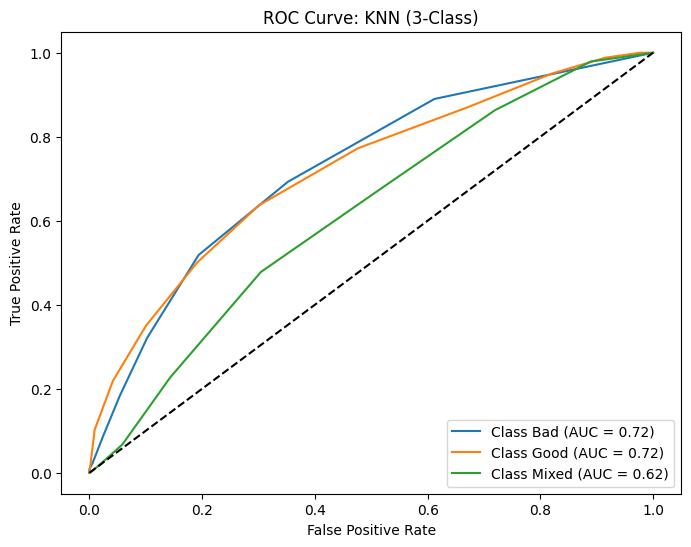

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_multiclass_roc(pipeline, X_test, y_test, classes, model_name):
    y_test_bin = label_binarize(y_test, classes=range(len(classes)))#binarize output for multi-class ROC
    n_classes = y_test_bin.shape[1]

    y_score = pipeline.predict_proba(X_test) # Get probability scores

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend(loc="lower right")
    plt.show()

# (5-class)
plot_multiclass_roc(clf_pipelines['Naive Bayes'], X_test_raw, y_clf_test, le.classes_, "Naive Bayes (5-Class)")
plot_multiclass_roc(clf_pipelines['Logistic Regression'], X_test_raw, y_clf_test, le.classes_, "Logistic Regression (5-Class)")
plot_multiclass_roc(clf_pipelines['Random Forest'], X_test_raw, y_clf_test, le.classes_, "Random Forest (5-Class)")
plot_multiclass_roc(clf_pipelines['XGBoost'], X_test_raw, y_clf_test, le.classes_, "XGBoost (5-Class)")
plot_multiclass_roc(clf_pipelines['KNN'], X_test_raw, y_clf_test, le.classes_, "KNN (5-Class)")

# (3-class)
plot_multiclass_roc(clf3_pipelines['Logistic Regression'], X_test_raw, y_clf3_test, le3.classes_, "Logistic Regression (3-Class)")
plot_multiclass_roc(clf3_pipelines['Random Forest'], X_test_raw, y_clf3_test, le3.classes_, "Random Forest (3-Class)")
plot_multiclass_roc(clf3_pipelines['XGBoost'], X_test_raw, y_clf3_test, le3.classes_, "XGBoost (3-Class)")
plot_multiclass_roc(clf3_pipelines['KNN'], X_test_raw, y_clf3_test, le3.classes_, "KNN (3-Class)")

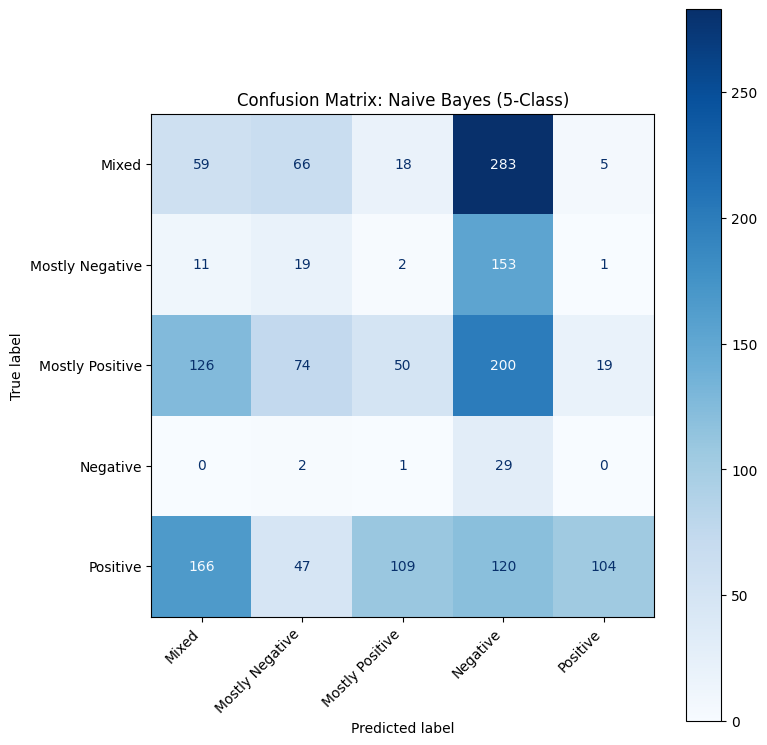

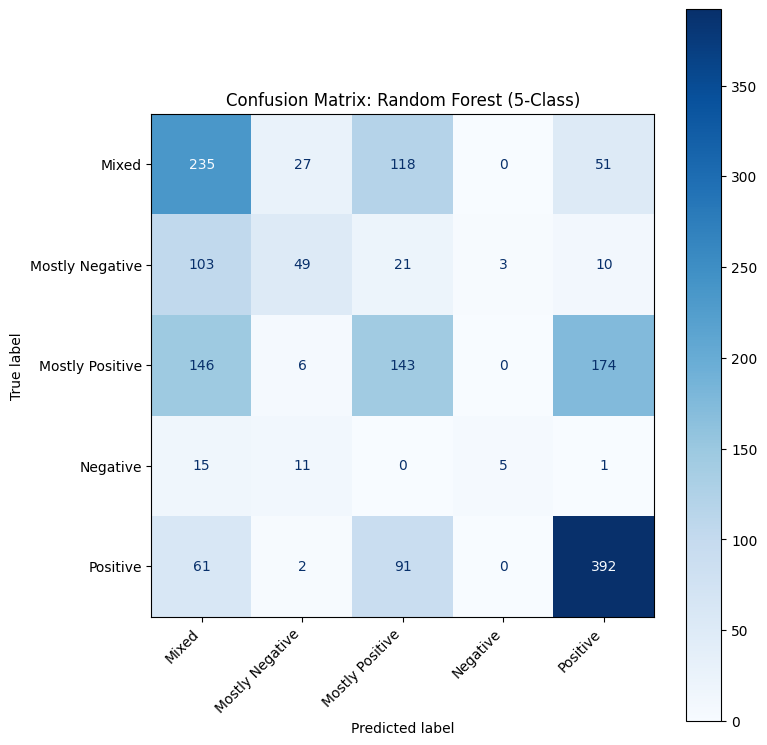

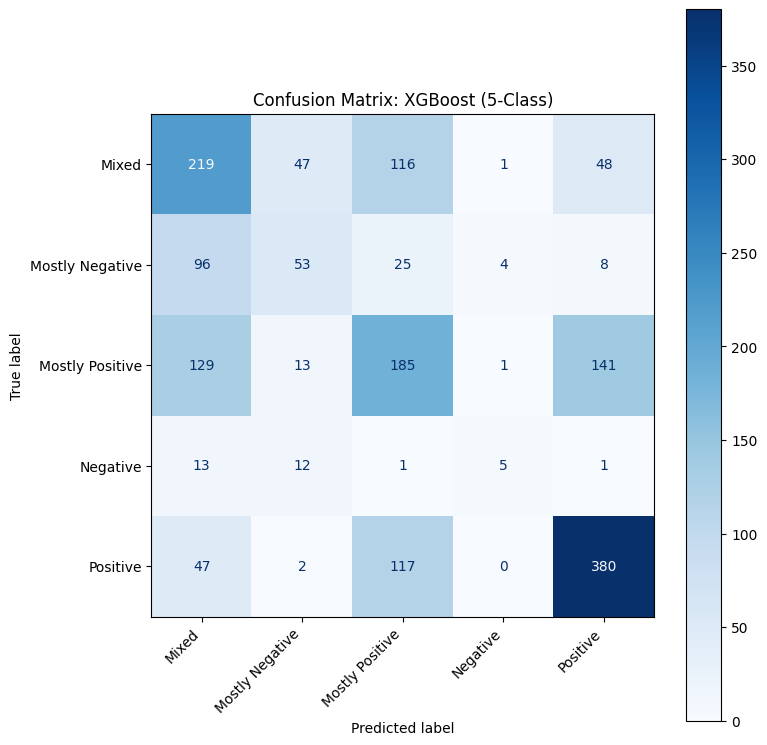

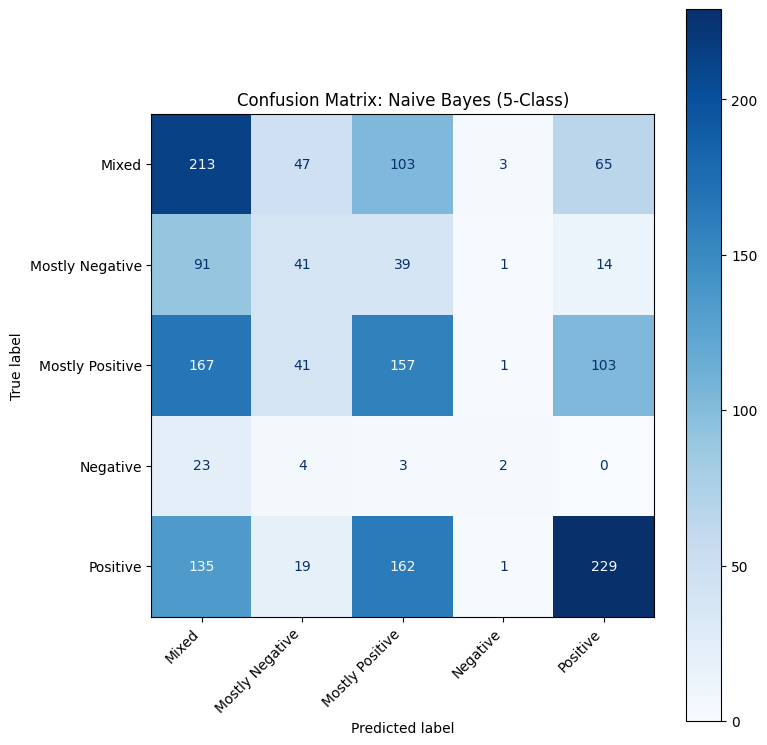

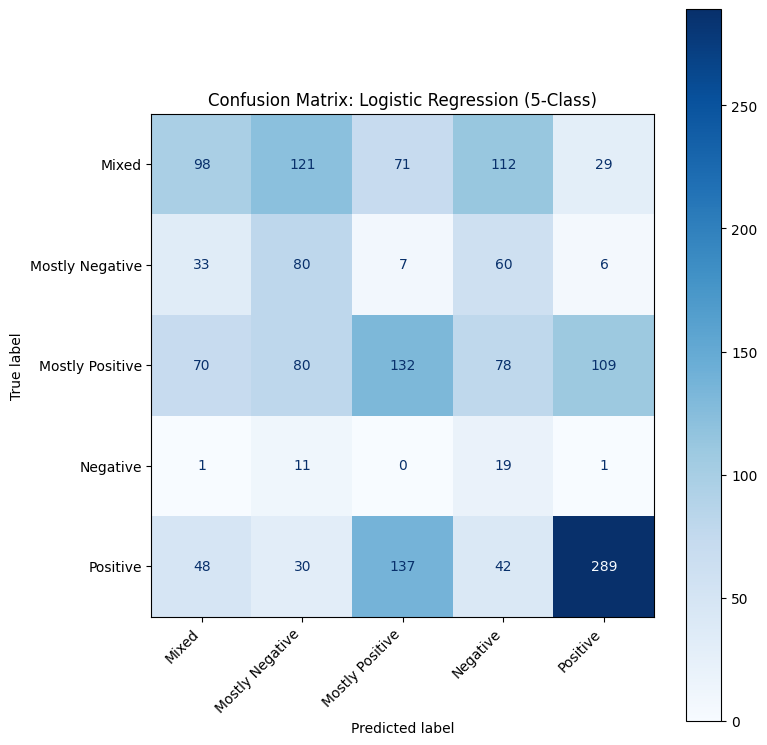

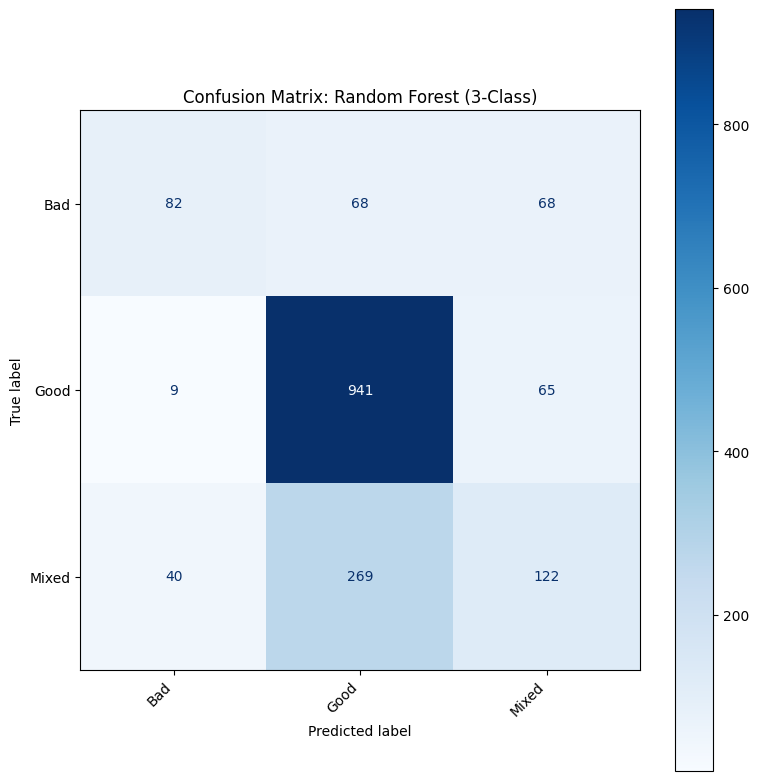

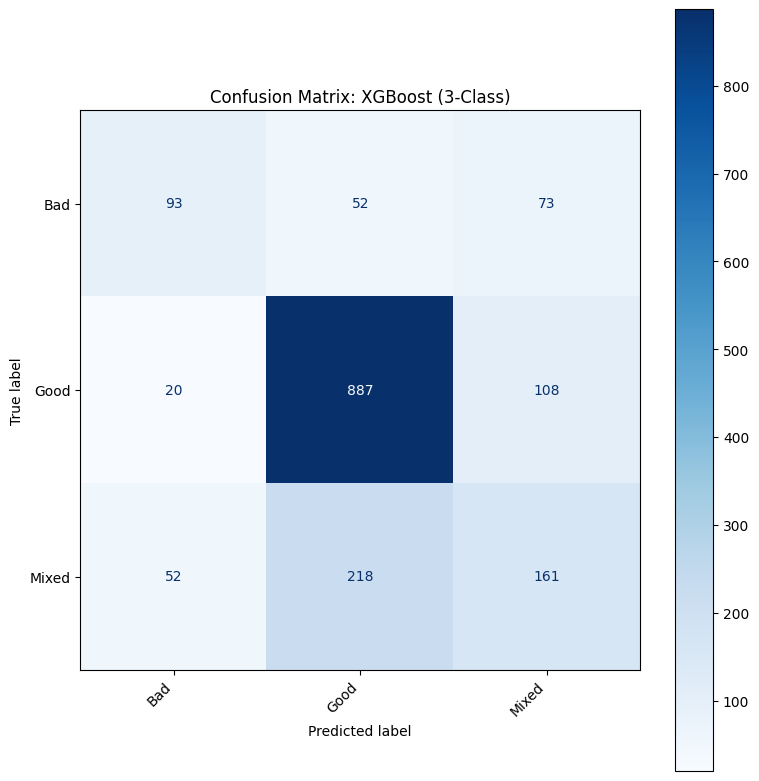

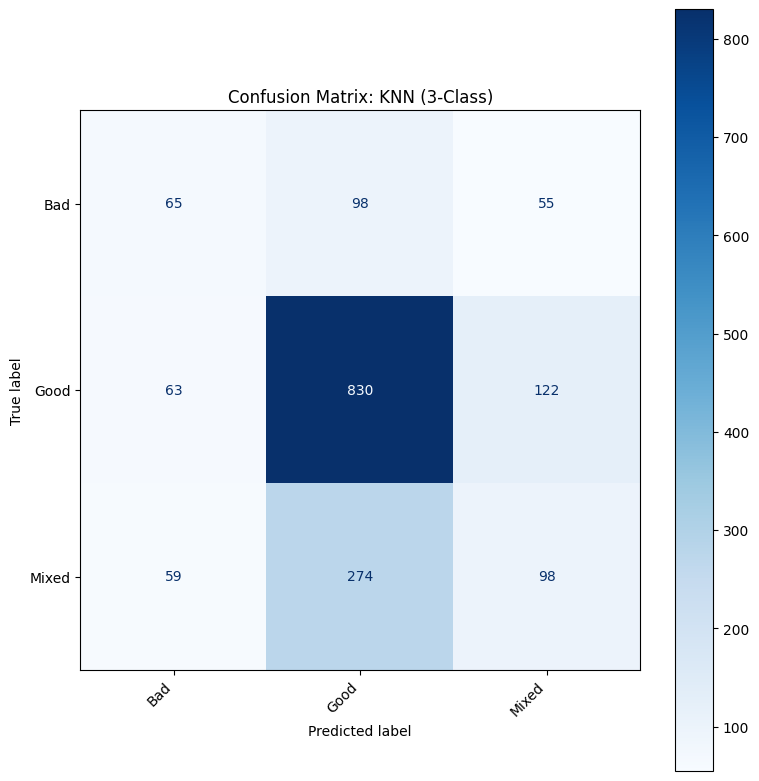

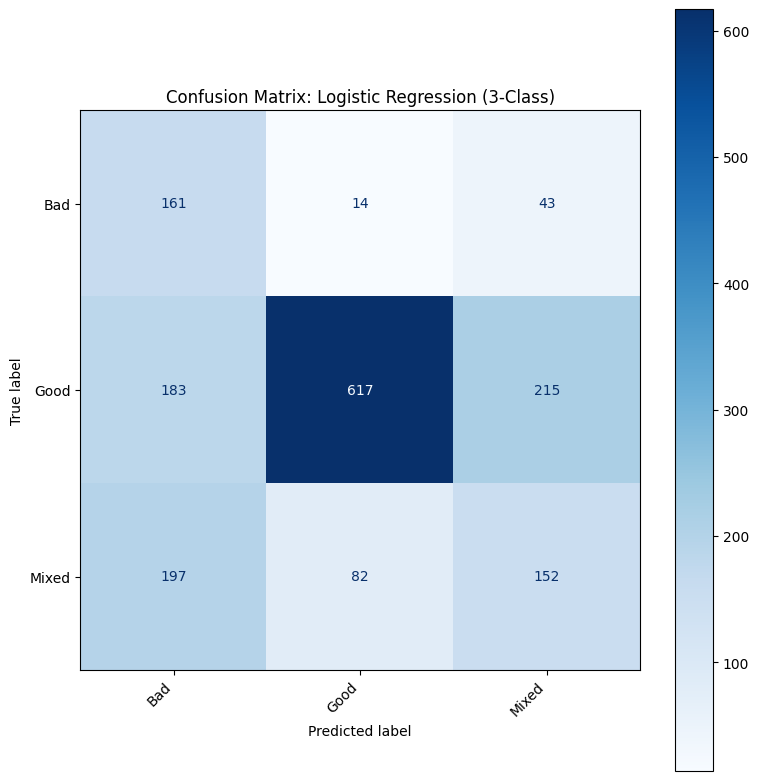

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def show_confusion_matrix(pipeline, X_test, y_test, classes, title):
    preds = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f"Confusion Matrix: {title}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


#clf
show_confusion_matrix(clf_pipelines['Naive Bayes'], X_test_raw, y_clf_test, le.classes_, "Naive Bayes (5-Class)")
show_confusion_matrix(clf_pipelines['Random Forest'], X_test_raw, y_clf_test, le.classes_, "Random Forest (5-Class)")
show_confusion_matrix(clf_pipelines['XGBoost'], X_test_raw, y_clf_test, le.classes_, "XGBoost (5-Class)")
show_confusion_matrix(clf_pipelines['KNN'], X_test_raw, y_clf_test, le.classes_, "Naive Bayes (5-Class)")
show_confusion_matrix(clf_pipelines['Logistic Regression'], X_test_raw, y_clf_test, le.classes_, "Logistic Regression (5-Class)")

#clf3
show_confusion_matrix(clf3_pipelines['Random Forest'], X_test_raw, y_clf3_test, le3.classes_, "Random Forest (3-Class)")
show_confusion_matrix(clf3_pipelines['XGBoost'], X_test_raw, y_clf3_test, le3.classes_, "XGBoost (3-Class)")
show_confusion_matrix(clf3_pipelines['KNN'], X_test_raw, y_clf3_test, le3.classes_, "KNN (3-Class)")
show_confusion_matrix(clf3_pipelines['Logistic Regression'], X_test_raw, y_clf3_test, le3.classes_, "Logistic Regression (3-Class)")


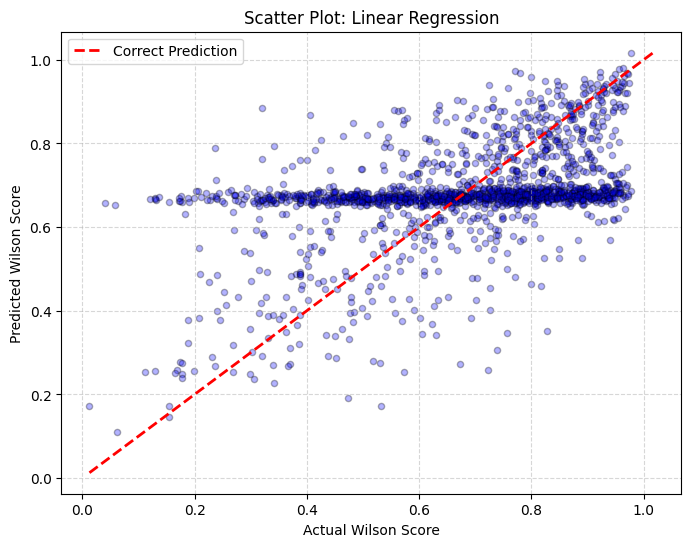

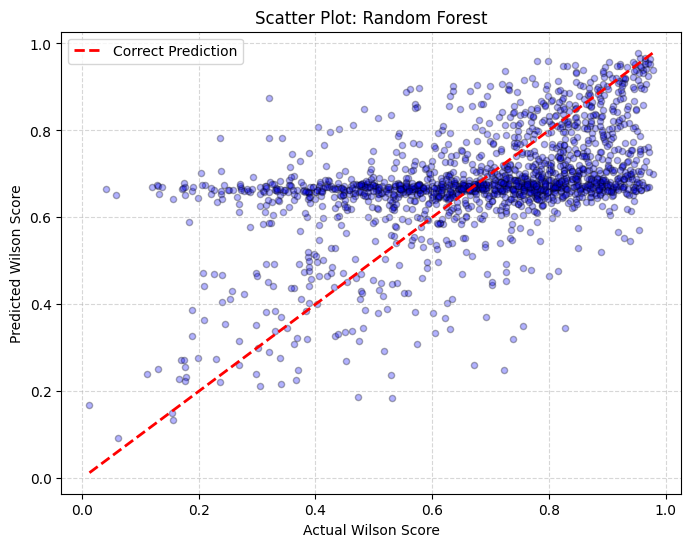

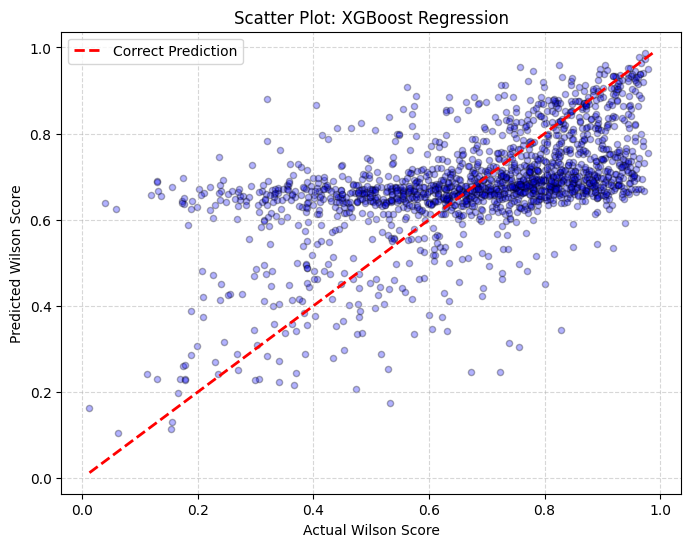

In [42]:
import matplotlib.pyplot as plt

def plot_regression_results(pipeline, X_test, y_test, model_name):
    preds = pipeline.predict(X_test)

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, preds, alpha=0.3, c='blue', edgecolors='k', s=20)

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Correct Prediction')

    plt.title(f'Scatter Plot: {model_name}')
    plt.xlabel('Actual Wilson Score')
    plt.ylabel('Predicted Wilson Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_regression_results(reg_pipelines['Linear Regression'], X_test_raw, y_reg_test, "Linear Regression")
plot_regression_results(reg_pipelines['Random Forest'], X_test_raw, y_reg_test, "Random Forest")
plot_regression_results(reg_pipelines['XGBoost'], X_test_raw, y_reg_test, "XGBoost Regression")

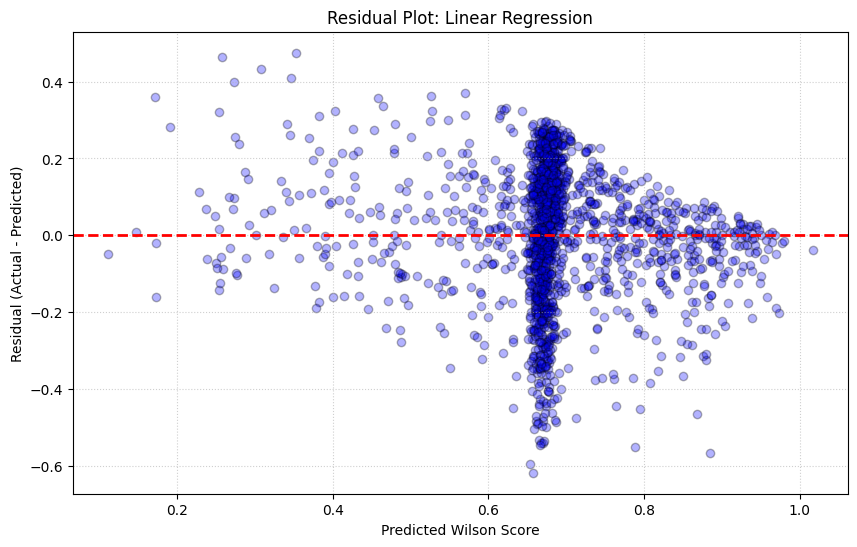

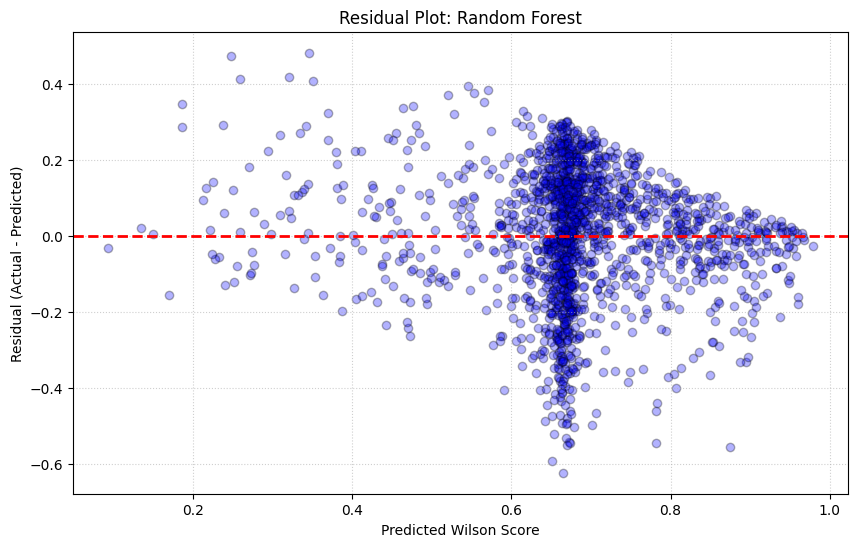

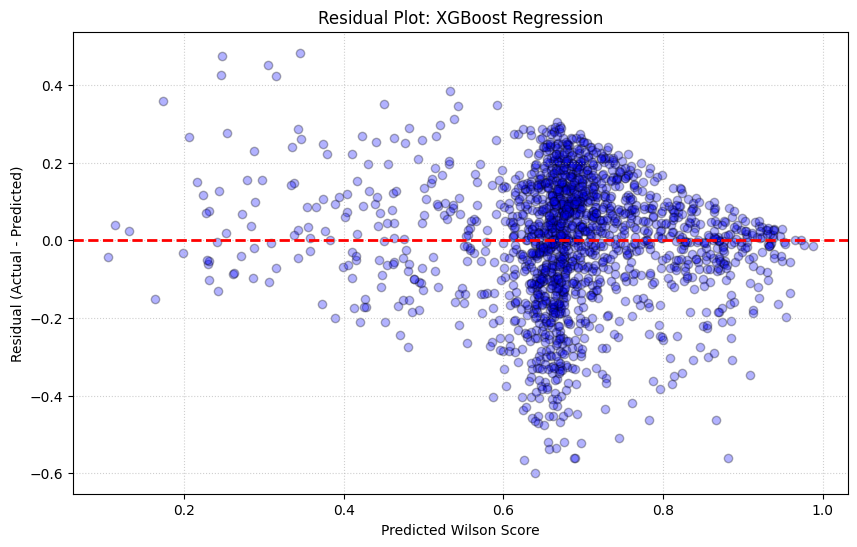

In [41]:
def plot_residuals(pipeline, X_test, y_test, model_name):
    preds = pipeline.predict(X_test)
    residuals = y_test - preds

    plt.figure(figsize=(10, 6))
    plt.scatter(preds, residuals, alpha=0.3, c='blue', edgecolors='k')

    plt.axhline(y=0, color='red', linestyle='--', lw=2) #line at 0 when error is 0

    plt.title(f'Residual Plot: {model_name}')
    plt.xlabel('Predicted Wilson Score')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_residuals(reg_pipelines['Linear Regression'], X_test_raw, y_reg_test, "Linear Regression")
plot_residuals(reg_pipelines['Random Forest'], X_test_raw, y_reg_test, "Random Forest")
plot_residuals(reg_pipelines['XGBoost'], X_test_raw, y_reg_test, "XGBoost Regression")

## Residual Diagnosis & Target Transformation

Wilson score is bounded in **[0, 1]**. When predicted values approach the ceiling (≈1) there is simply less room for positive residuals, producing a structural **heteroscedasticity (fanning-in)** pattern. The natural remedy for a bounded proportion is the **logit transform**, which maps (0,1) → (−∞,+∞) and removes the boundary constraint.

In [18]:
# ── Heteroscedasticity Diagnosis ────────────────────────────────────────
from scipy import stats

print('Heteroscedasticity Check: Spearman ρ(|residuals|, predicted)')
print('=' * 60)

for name, pipe in reg_pipelines.items():
    preds = pipe.predict(X_test_raw)
    res   = y_reg_test.values - preds

    # Spearman correlation between absolute residuals and predicted values
    rho, p_val = stats.spearmanr(preds, np.abs(res))
    print(f'{name:22s}  rho = {rho:+.4f}  (p = {p_val:.4f})')

    # Binned residual std by predicted quartile
    bins = np.percentile(preds, [0, 25, 50, 75, 100])
    stds = []
    for i in range(4):
        mask = (preds >= bins[i]) & (preds <= bins[i+1])
        stds.append(res[mask].std())
    print(f'  Residual std by quartile: {[round(s,4) for s in stds]}')
    print()

print('Interpretation:')
print('  Negative rho -> variance DECREASES at higher predictions (fanning-in).')
print('  This is a ceiling effect from the [0,1] bound on Wilson score.')
print('  -> Apply logit transform to stabilise variance.')


Heteroscedasticity Check: Spearman ρ(|residuals|, predicted)
Linear Regression       rho = -0.1619  (p = 0.0000)
  Residual std by quartile: [np.float64(0.1795), np.float64(0.196), np.float64(0.1746), np.float64(0.132)]

Random Forest           rho = -0.1900  (p = 0.0000)
  Residual std by quartile: [np.float64(0.177), np.float64(0.1962), np.float64(0.1621), np.float64(0.1302)]

XGBoost                 rho = -0.2150  (p = 0.0000)
  Residual std by quartile: [np.float64(0.1738), np.float64(0.1899), np.float64(0.1503), np.float64(0.1239)]

Interpretation:
  Negative rho -> variance DECREASES at higher predictions (fanning-in).
  This is a ceiling effect from the [0,1] bound on Wilson score.
  -> Apply logit transform to stabilise variance.


In [19]:
# ── Logit Transformation of Wilson Score ────────────────────────────────
from scipy.special import logit, expit
from sklearn.base import clone

eps = 1e-4  # clip to avoid log(0)
y_logit = logit(y_reg.clip(eps, 1 - eps))

print('Wilson score stats (original):')
print(pd.Series(y_reg.values).describe().round(4))
print('\nlogit(Wilson score) stats:')
print(pd.Series(y_logit).describe().round(4))

# Same split as before (random_state=42, stratify=y_clf)
_, _, _, _, _, _, y_lt_train, y_lt_test = train_test_split(
    X, y_clf, y_clf3, y_logit,
    test_size=0.2, random_state=42, stratify=y_clf
)

print('\nRefitting regression models on logit(wilson_score)...')
print('=' * 60)

reg_logit_pipes   = {}
reg_logit_results = {}

for name, pipe in reg_pipelines.items():
    p_clone = clone(pipe)
    p_clone.fit(X_train_raw, y_lt_train)
    preds_lt   = p_clone.predict(X_test_raw)
    reg_logit_pipes[name] = p_clone

    r2_lt   = r2_score(y_lt_test, preds_lt)
    rmse_lt = np.sqrt(mean_squared_error(y_lt_test, preds_lt))

    # Back-transform for comparison on original scale
    preds_orig = expit(preds_lt)
    r2_orig    = r2_score(expit(y_lt_test), preds_orig)

    reg_logit_results[name] = {
        'R2_logit':  round(r2_lt,   4),
        'RMSE_logit': round(rmse_lt, 4),
        'R2_orig':   round(r2_orig,  4),
    }
    print(f'{name:22s}  R2(logit)={r2_lt:.4f}  '
          f'RMSE(logit)={rmse_lt:.4f}  R2(orig)={r2_orig:.4f}')

# Side-by-side comparison table
print('\n--- R² comparison: original vs logit-transformed target ---')
print(f'{"Model":<22}  {"R2 original":>12}  {"R2 orig-scale (logit fit)":>25}')
for name in reg_pipelines:
    r2_old = reg_test_results[name]['R²']
    r2_new = reg_logit_results[name]['R2_orig']
    print(f'{name:<22}  {r2_old:>12.4f}  {r2_new:>25.4f}')


Wilson score stats (original):
count    8319.0000
mean        0.6753
std         0.1997
min         0.0000
25%         0.5444
50%         0.7146
75%         0.8358
max         0.9859
dtype: float64

logit(Wilson score) stats:
count    8319.0000
mean        0.8948
std         1.0819
min        -9.2102
25%         0.1779
50%         0.9181
75%         1.6270
max         4.2464
Name: wilson_score, dtype: float64

Refitting regression models on logit(wilson_score)...
Linear Regression       R2(logit)=0.2463  RMSE(logit)=0.9379  R2(orig)=0.2193
Random Forest           R2(logit)=0.2863  RMSE(logit)=0.9127  R2(orig)=0.2476
XGBoost                 R2(logit)=0.3432  RMSE(logit)=0.8755  R2(orig)=0.3025

--- R² comparison: original vs logit-transformed target ---
Model                    R2 original  R2 orig-scale (logit fit)
Linear Regression             0.2334                     0.2193
Random Forest                 0.2675                     0.2476
XGBoost                       0.3232         

In [21]:
import matplotlib.pyplot as plt

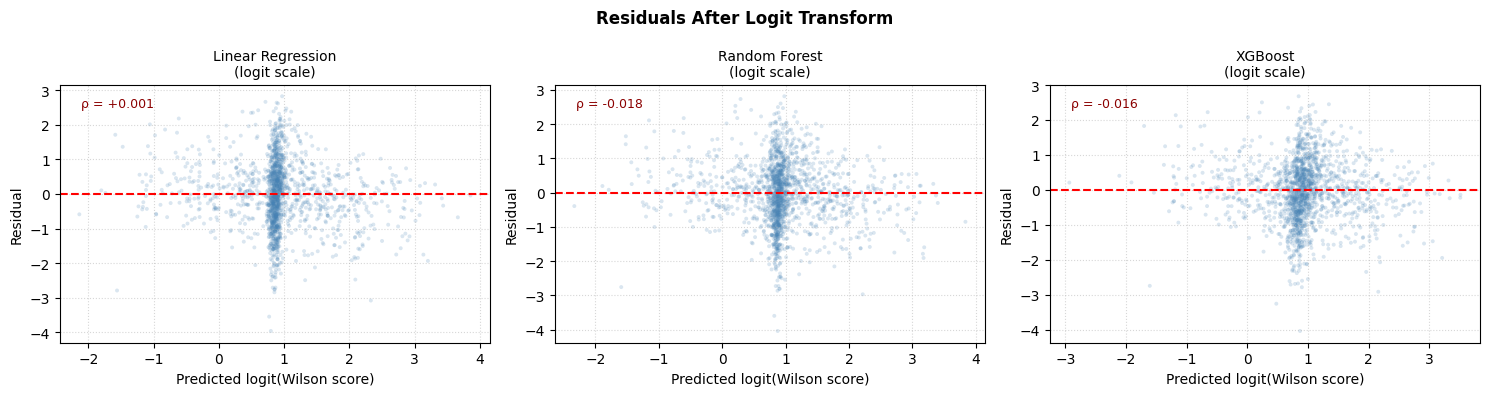

In [22]:
# ── Residual Plots: Logit-Transformed Target ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipe) in zip(axes, reg_logit_pipes.items()):
    preds = pipe.predict(X_test_raw)
    res   = y_lt_test.values - preds

    ax.scatter(preds, res, alpha=0.2, s=8, c='steelblue', edgecolors='none')
    ax.axhline(0, color='red', lw=1.5, linestyle='--')
    ax.set_title(f'{name}\n(logit scale)', fontsize=10)
    ax.set_xlabel('Predicted logit(Wilson score)')
    ax.set_ylabel('Residual')
    ax.grid(True, linestyle=':', alpha=0.5)

    # Spearman rho annotation
    from scipy import stats
    rho, _ = stats.spearmanr(preds, np.abs(res))
    ax.text(0.05, 0.95, f'ρ = {rho:+.3f}', transform=ax.transAxes,
            fontsize=9, va='top', color='darkred')

plt.suptitle('Residuals After Logit Transform', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [23]:
# ── Global F-Test for Linear Regression ─────────────────────────────────
# H0: all regression coefficients = 0 (model explains no variance)
# F = (R2/p) / ((1-R2)/(n-p-1))
from scipy import stats

def global_f_test(pipe, X_test, y_test, label=''):
    preds = pipe.predict(X_test)
    r2    = r2_score(y_test, preds)
    n     = len(y_test)
    p     = pipe.named_steps['model'].coef_.shape[0]
    F     = (r2 / p) / ((1 - r2) / (n - p - 1))
    pv    = stats.f.sf(F, dfn=p, dfd=n - p - 1)
    print(f'{label}')
    print(f'  n={n}, p={p}, R2={r2:.4f}')
    print(f'  F-statistic = {F:.4f}')
    print(f'  p-value     = {pv:.4e}')
    verdict = 'REJECT H0' if pv < 0.05 else 'FAIL TO REJECT H0'
    action = 'explains' if pv < 0.05 else 'does NOT explain'
    print(f'  -> {verdict}: model {action} significant variance (alpha=0.05)')
    print()
    return F, pv

print('Global F-Test: H0 — all regression coefficients are zero')
print('=' * 60)

# Original scale
global_f_test(
    reg_pipelines['Linear Regression'], X_test_raw, y_reg_test,
    label='Linear Regression (original Wilson score)'
)

# Logit-transformed scale
global_f_test(
    reg_logit_pipes['Linear Regression'], X_test_raw, y_lt_test,
    label='Linear Regression (logit-transformed Wilson score)'
)

print('Note: F-test is evaluated on the held-out test set.')
print('A very large F with p << 0.05 confirms the model captures real signal,')
print('not noise — even though R2 is modest (~0.25 original, ~0.27 logit).')


Global F-Test: H0 — all regression coefficients are zero
Linear Regression (original Wilson score)
  n=1664, p=38, R2=0.2334
  F-statistic = 13.0225
  p-value     = 3.2776e-69
  -> REJECT H0: model explains significant variance (alpha=0.05)

Linear Regression (logit-transformed Wilson score)
  n=1664, p=38, R2=0.2463
  F-statistic = 13.9737
  p-value     = 9.2478e-75
  -> REJECT H0: model explains significant variance (alpha=0.05)

Note: F-test is evaluated on the held-out test set.
A very large F with p << 0.05 confirms the model captures real signal,
not noise — even though R2 is modest (~0.25 original, ~0.27 logit).
